# Interior cutaway comparison

This notebook cuts each predicted `.ply` mesh through its center and renders **Objective 1** beside the **interior expert**. The cut stays open so internal surfaces remain visible. Run it from the repository root with the TRELLIS environment; change `CUT_NORMAL` to `[0, 1, 0]` or `[0, 0, 1]` for another cut direction.

In [1]:
from pathlib import Path

import numpy as np
import pyvista as pv
from IPython.display import display
from PIL import Image

RESULTS_DIR = Path("results/geometry_expert/decoder_adapter_pilot/eval_test")
MESH_DIRS = {
    "Objective 1": RESULTS_DIR / "predictions/objective1/seed_42/mesh",
    "Interior expert": RESULTS_DIR / "predictions/interior_expert/seed_42/mesh",
}
CUT_NORMAL = np.array([1.0, 0.0, 0.0])  # remove the +X half
CUT_ORIGIN = (0.0, 0.0, 0.0)

sample_ids = [
    line.strip()
    for line in (RESULTS_DIR / "selected_ids.txt").read_text().splitlines()
    if line.strip()
]
print(f"Found {len(sample_ids)} test objects")

Found 20 test objects


car__e5aae7748aac94086228d448ae07dd2b


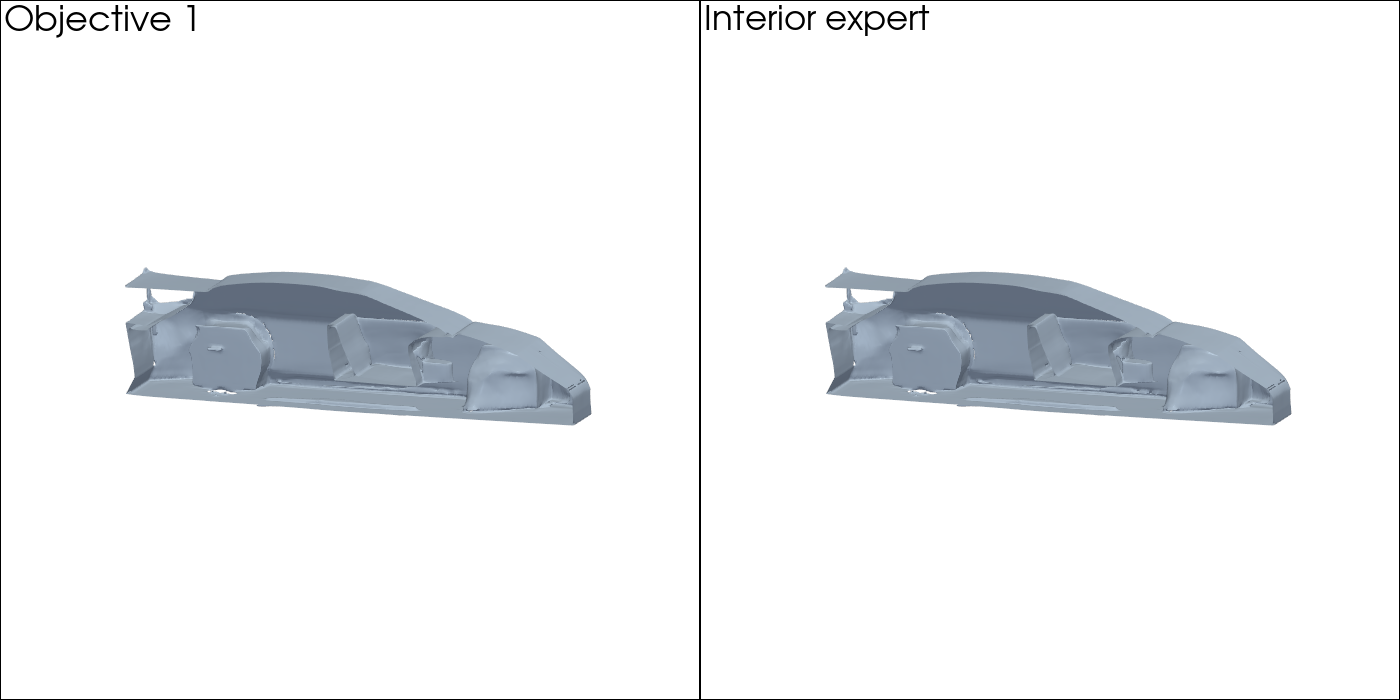

car__e64dd4ff16eab5752a9eb0f146e94477


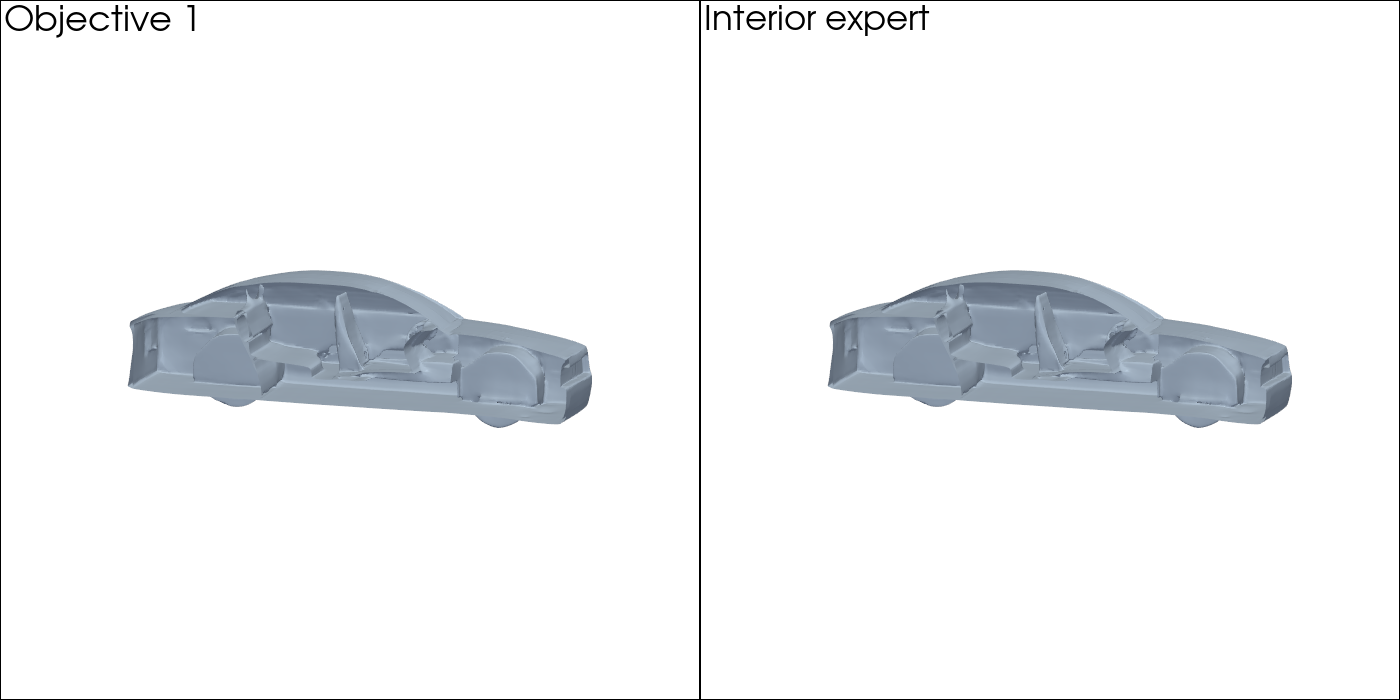

car__e66bbdf57fa6f7f575f257e5fe0a71cb


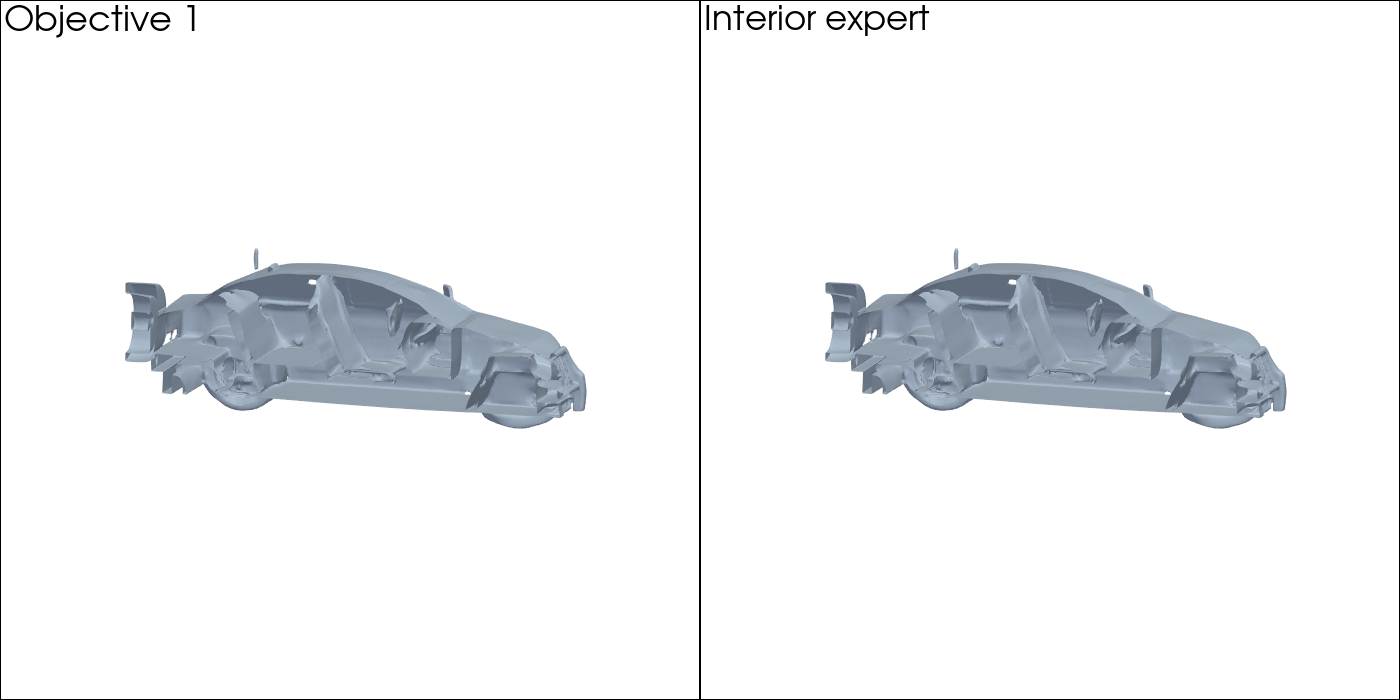

car__e67e3e3a21393927df59757e1209f2c7


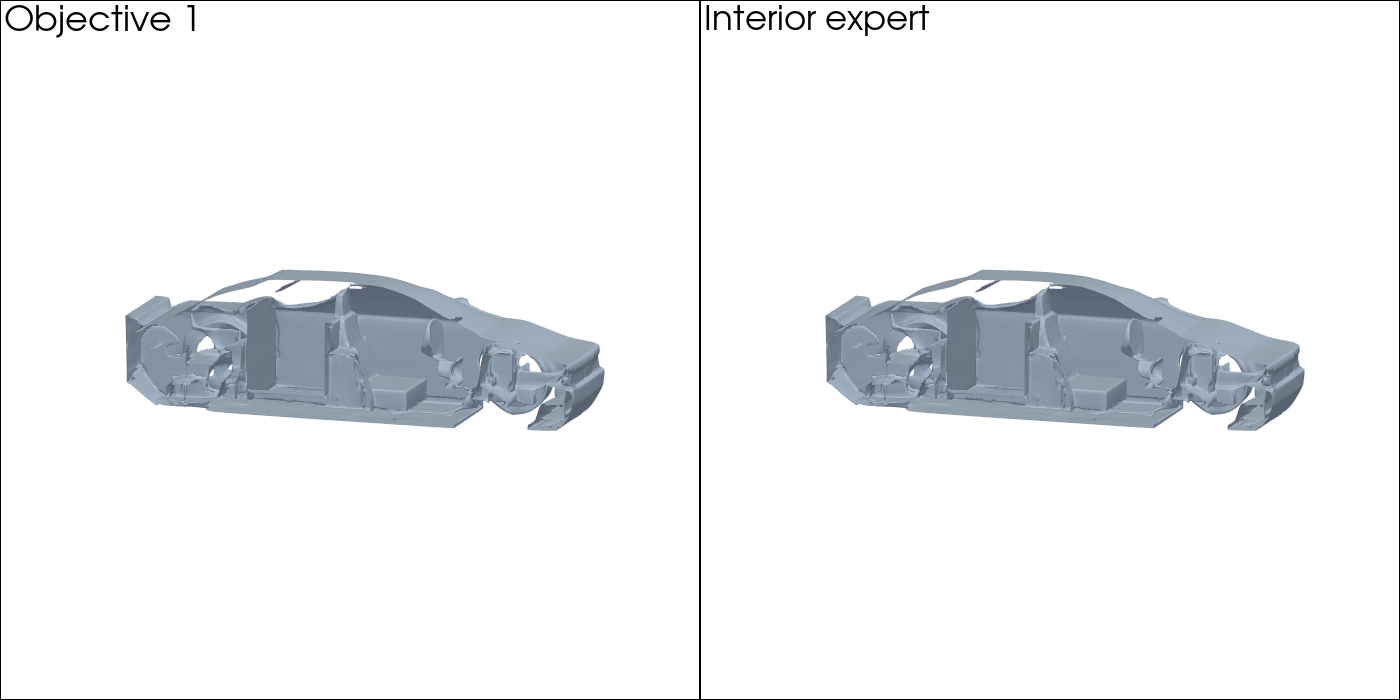

car__e69a5ad60aad3da2292296f0c84d7087


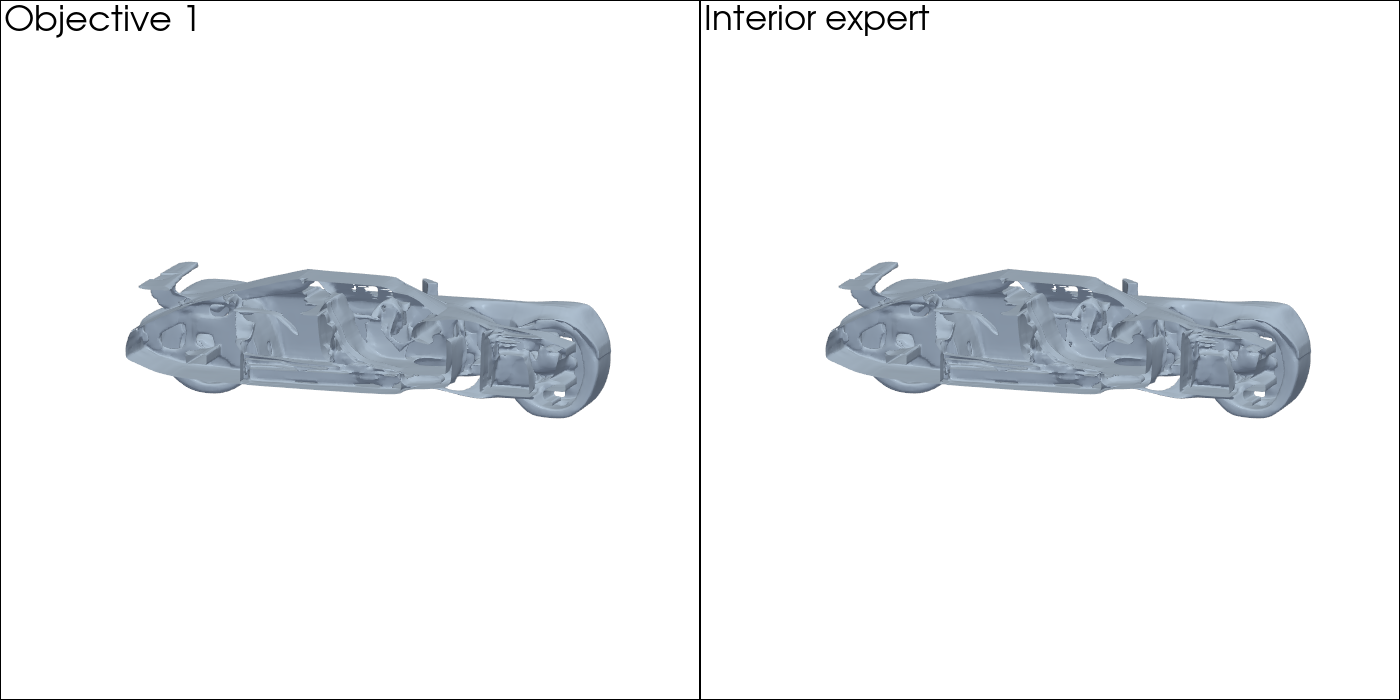

bus__e13587cf4367206627787a85c3bfabc6


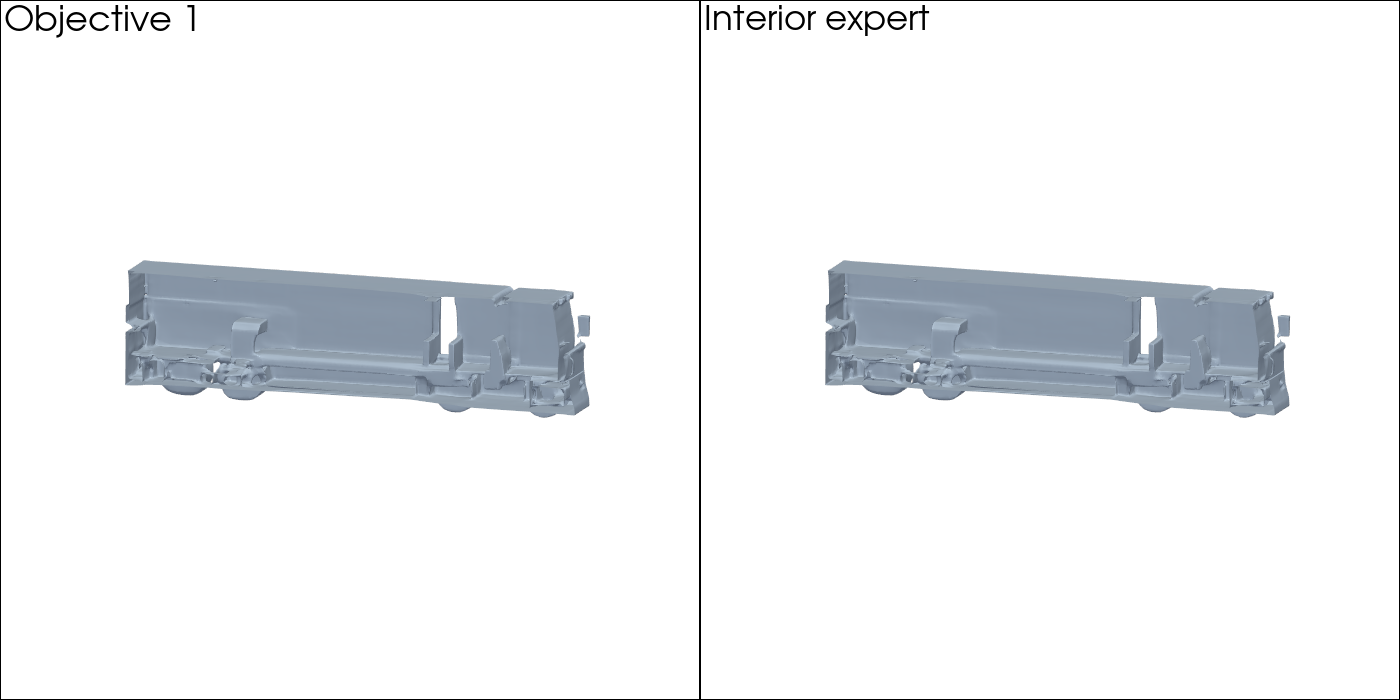

bus__e21827cb731e3e8d52d3524c5bacd7cf


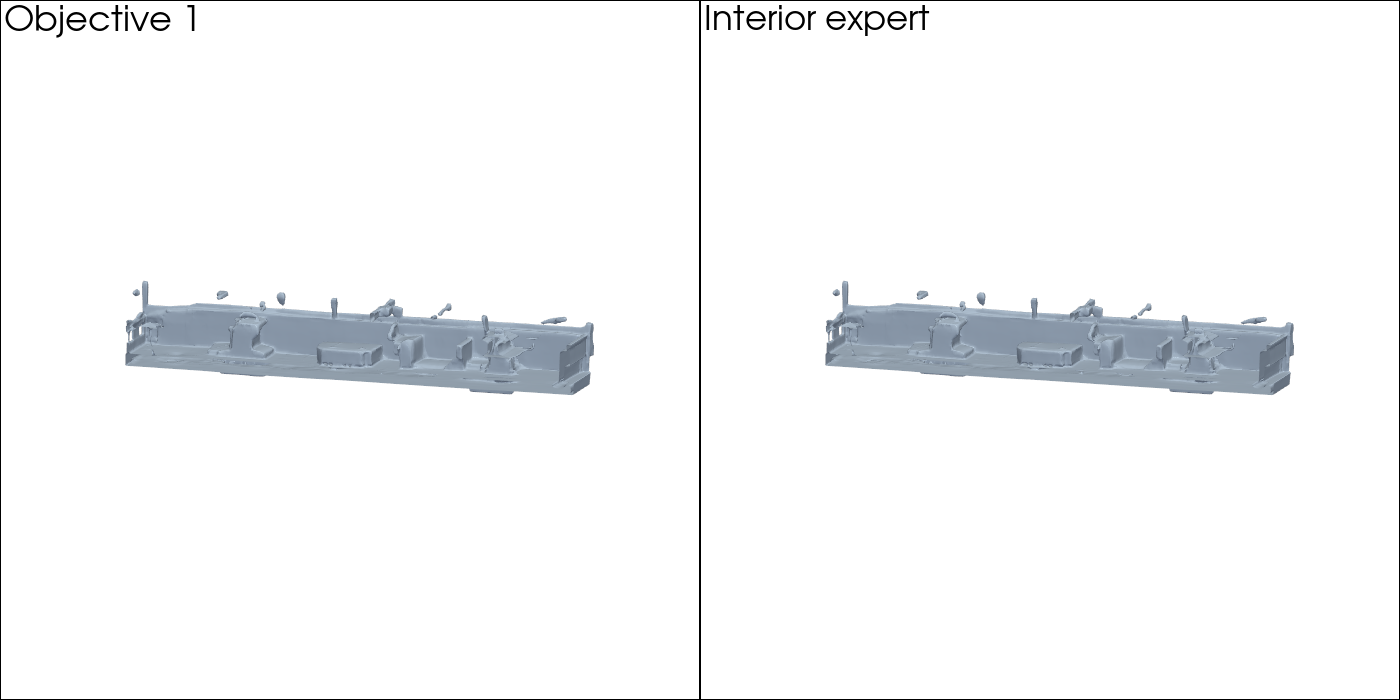

bus__e24cde6d0dd917c8a49d11719fd4710a


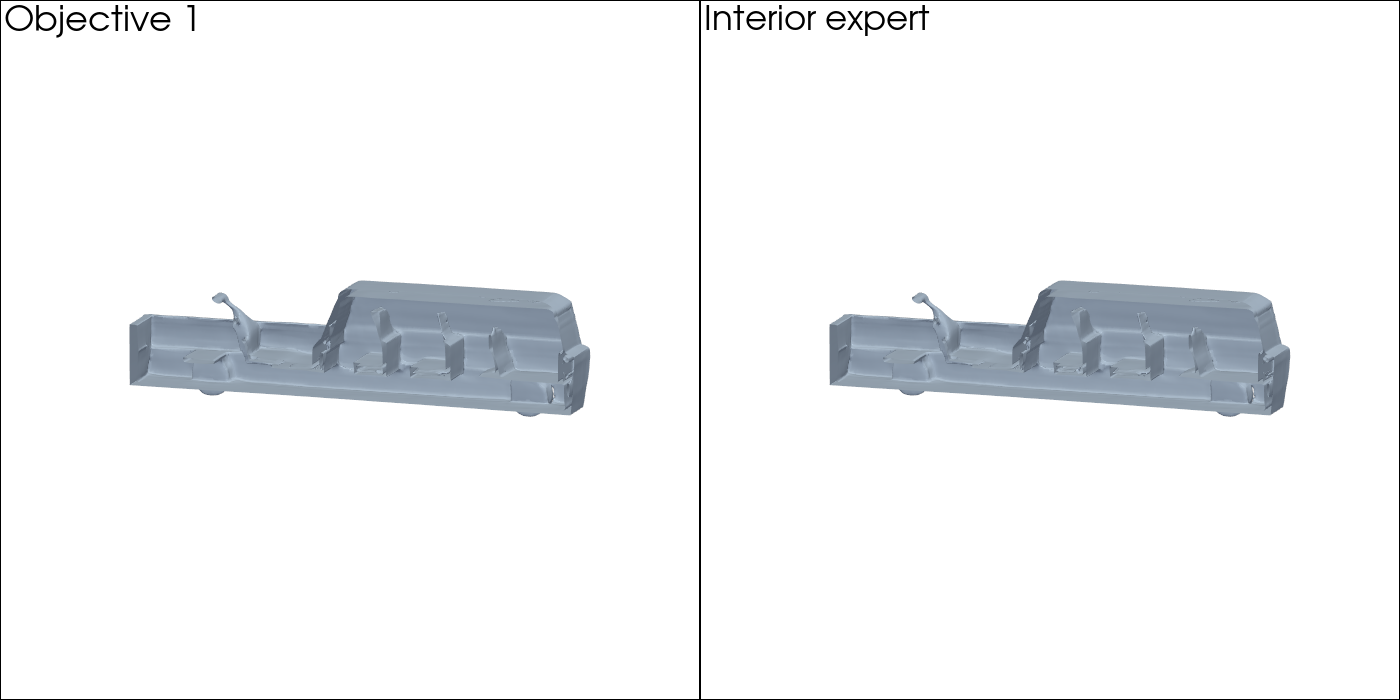

bus__e2c4d25593f1173cfa13d53e5e4a7d2a


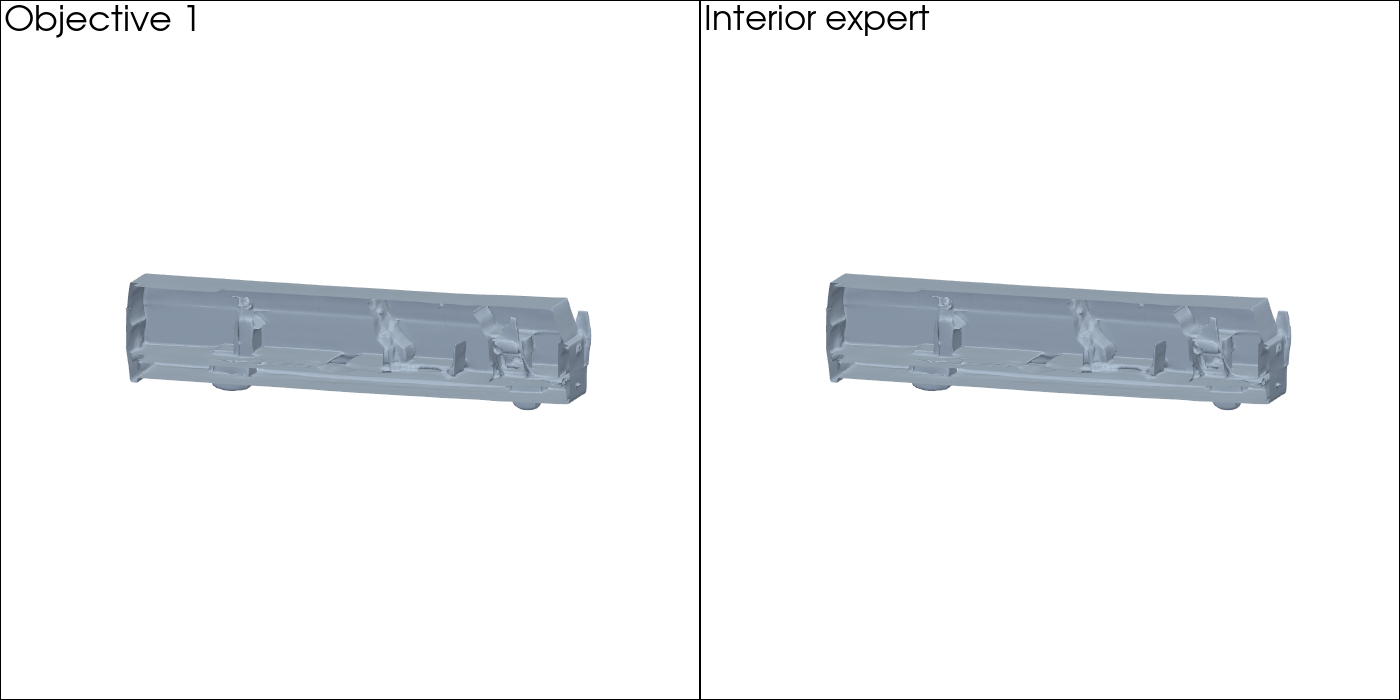

bus__e311aaea6c2662e7193d7855ecfc1bd3


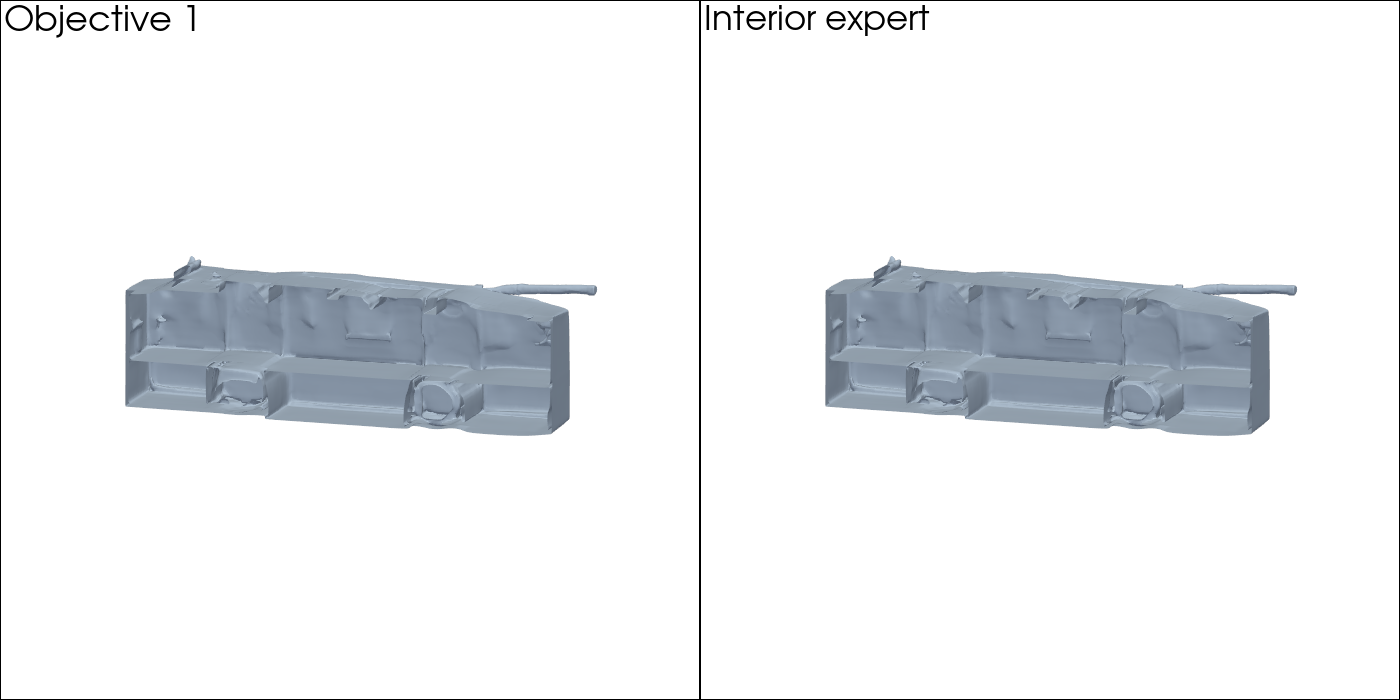

cabinet__ca9e248cdcca240f11a59b122fb65ee9


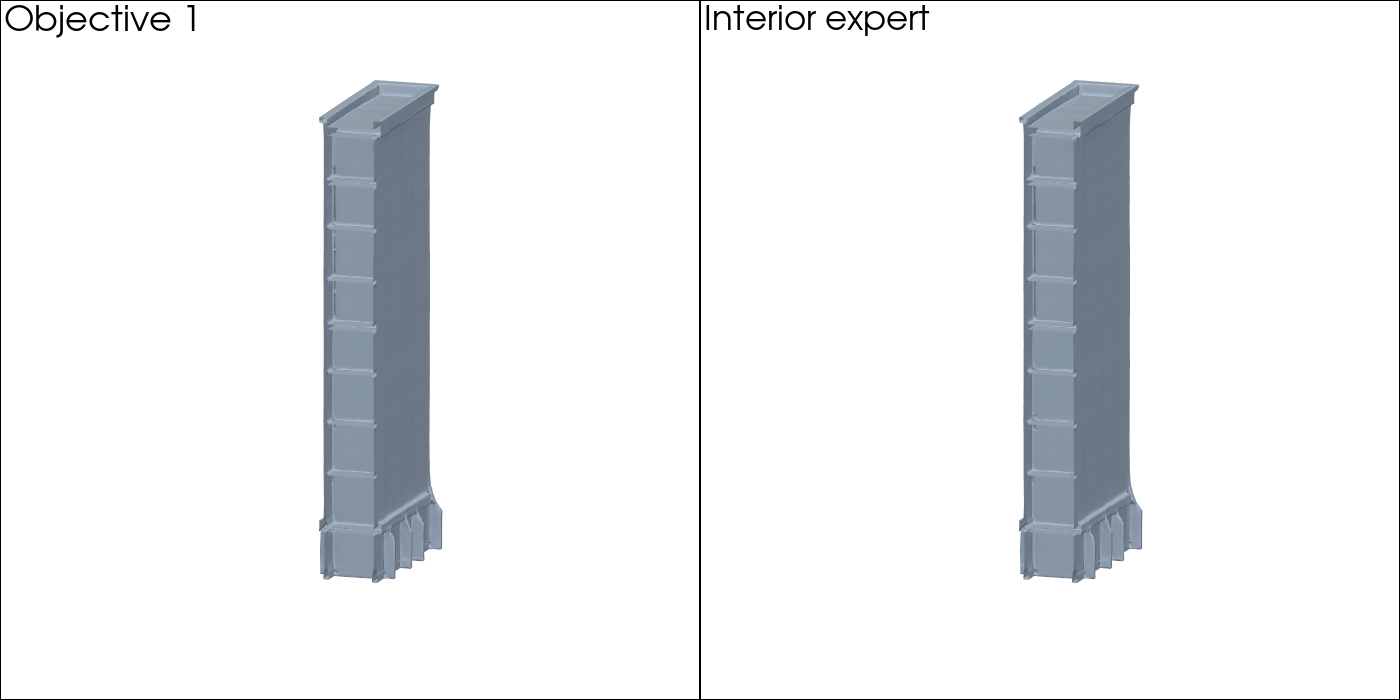

cabinet__caa4f65053f07a64548804f91c2c5c3d


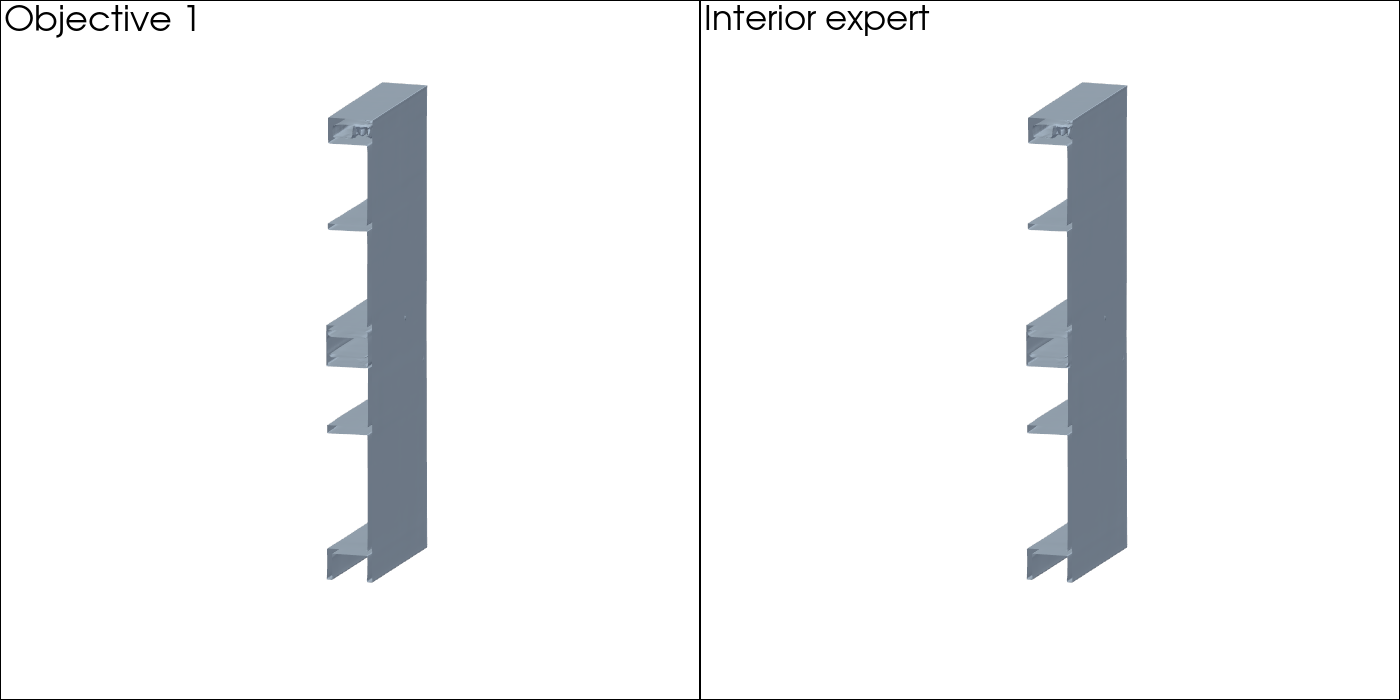

cabinet__cafb0ae07b0e2fb055f46d55537192b6


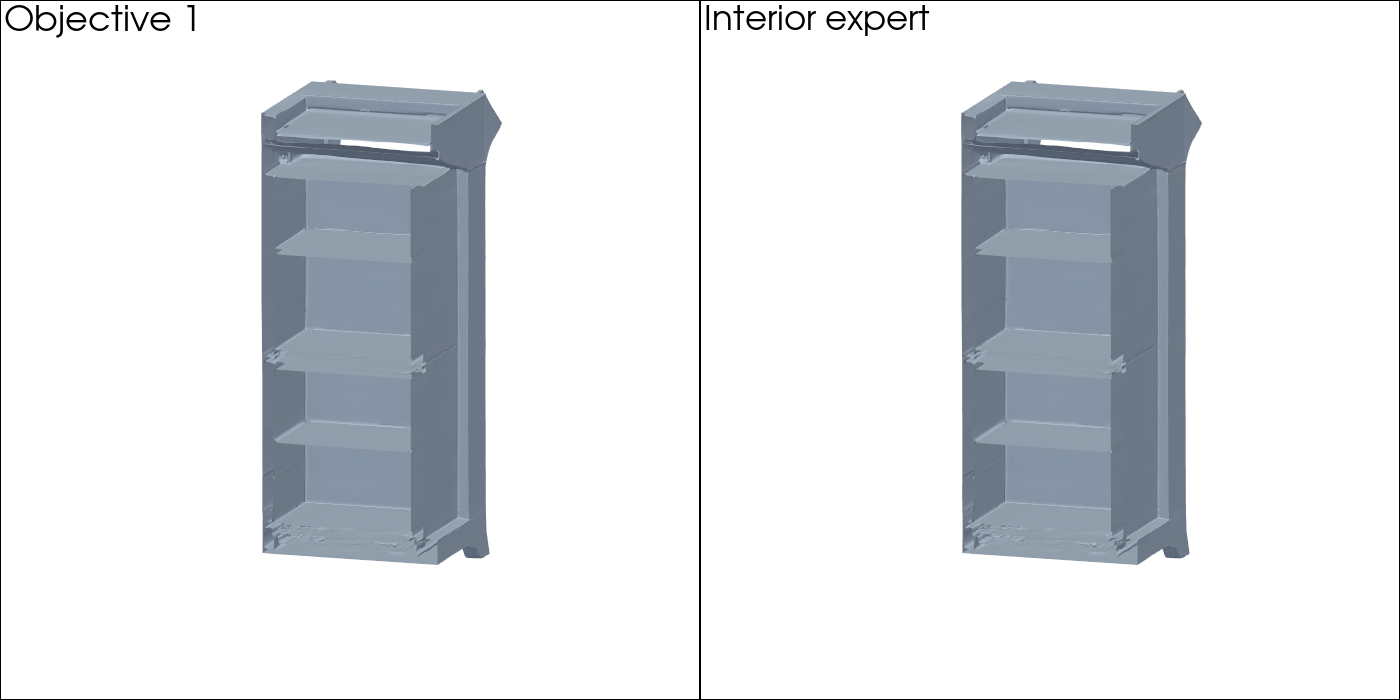

cabinet__cb12bf5a4429ed4c4639ab25a6c4afd9


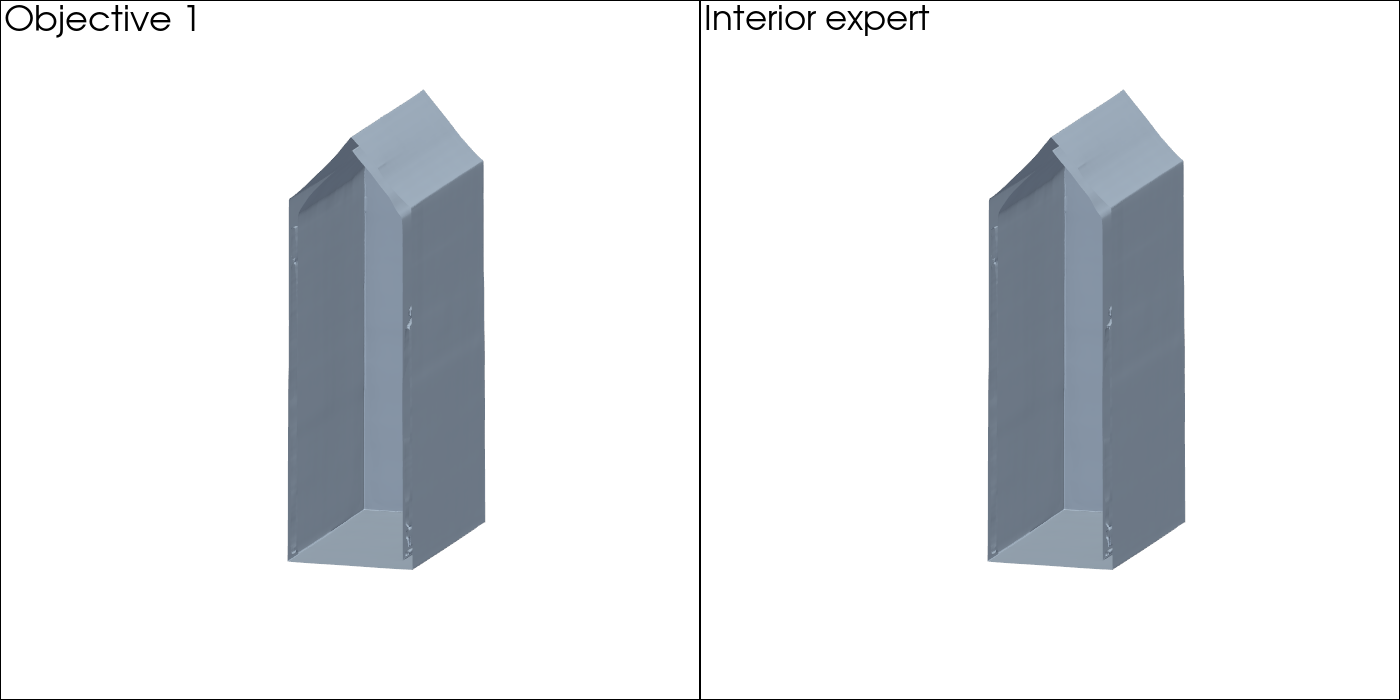

cabinet__cb506ccfb07faa60f51f77a6d7299806


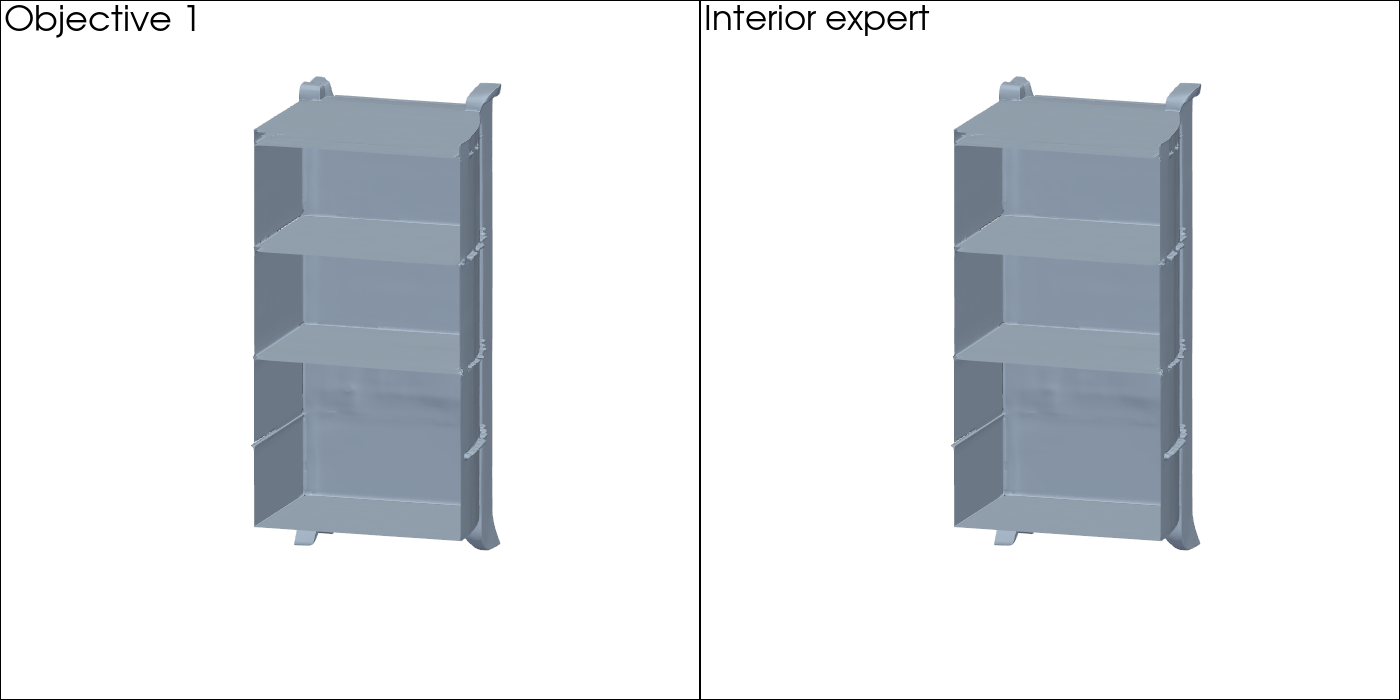

file_cabinet__db9fab17bc383c9e91c352d02061b3f7


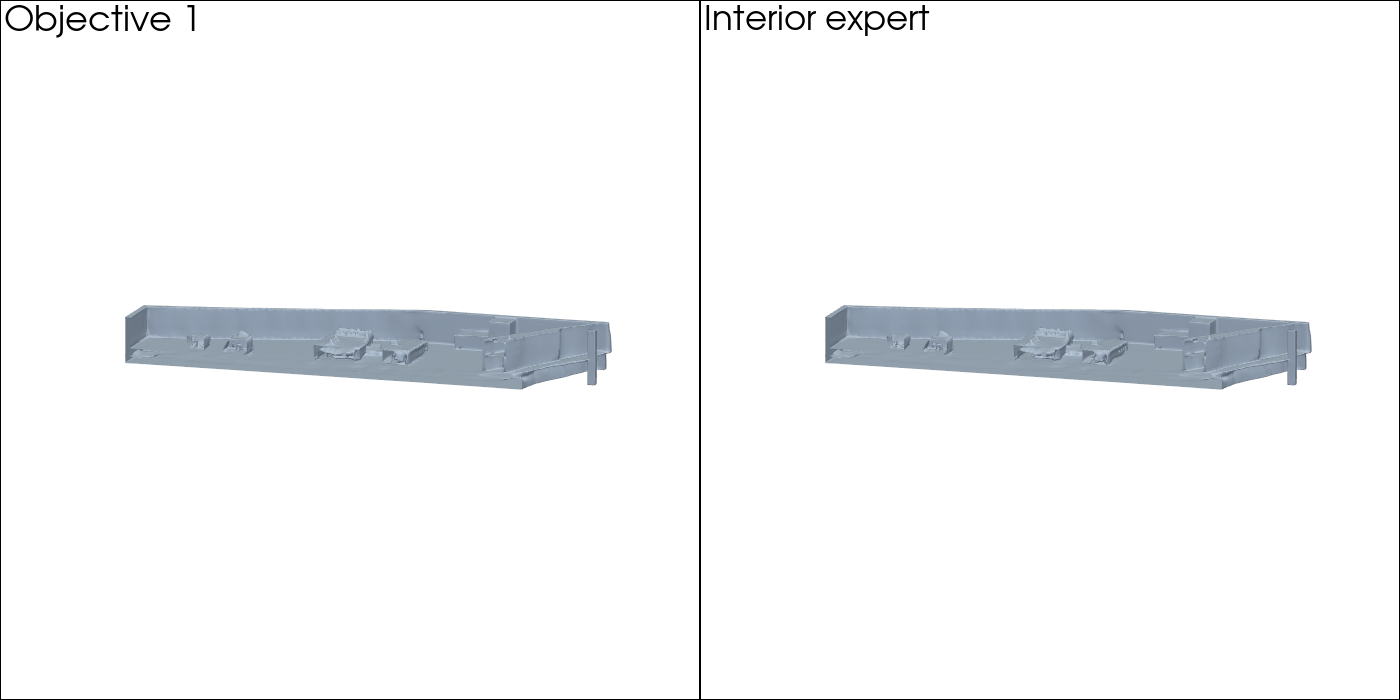

file_cabinet__dbf34becc9a4e4c34c3aee8e9d3a6ffa


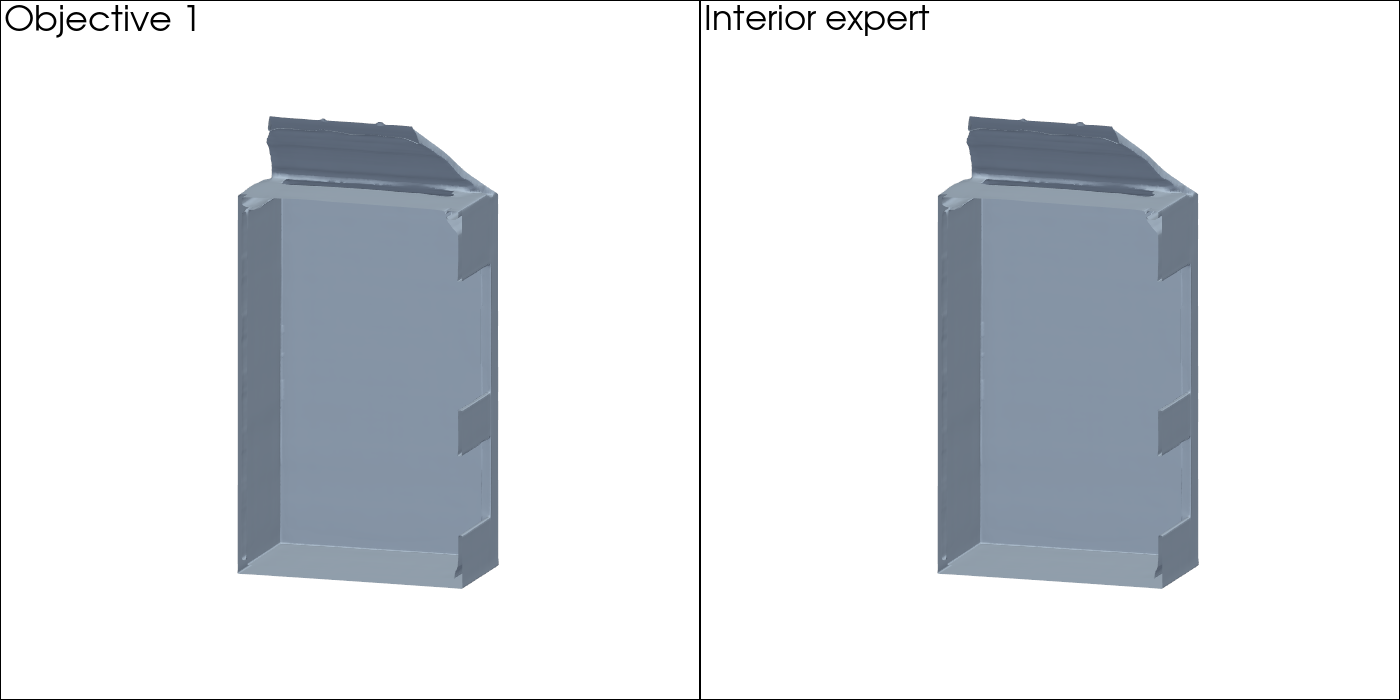

file_cabinet__de98cdf56188a576731d11154716a6b8


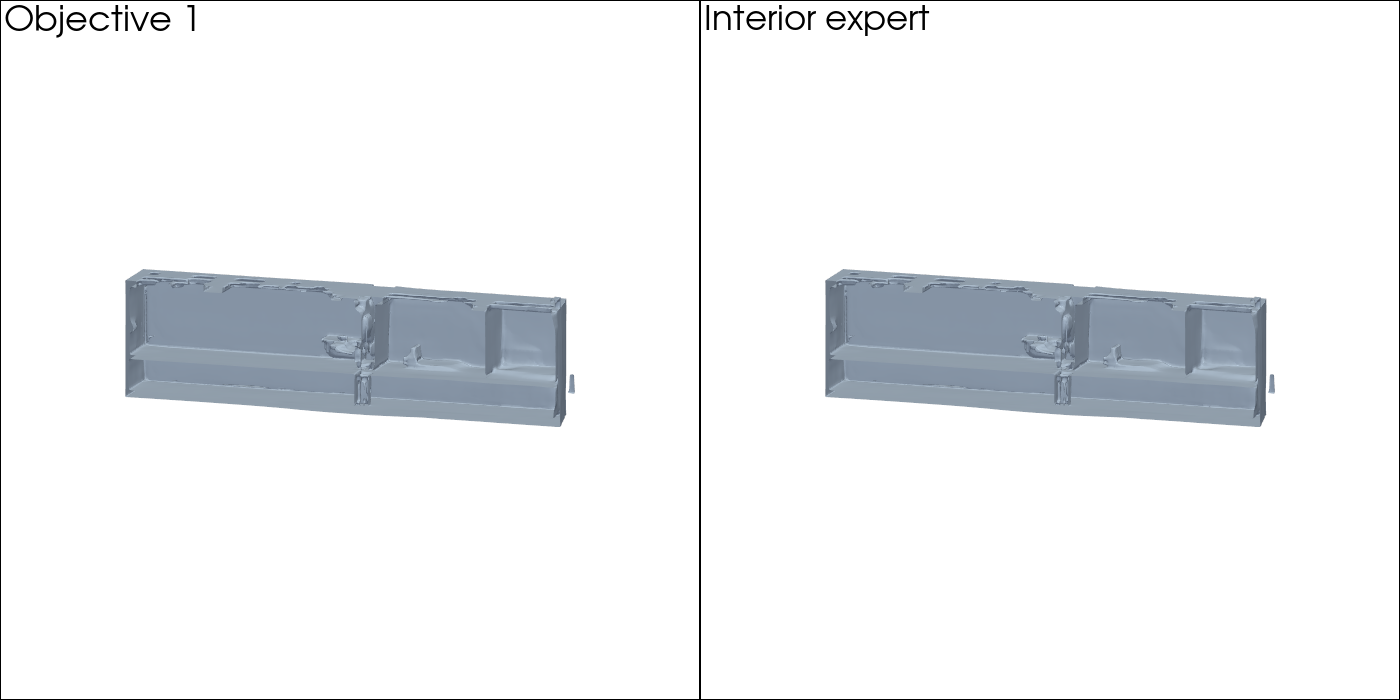

file_cabinet__df26b9e9e3c642e0e7ecdbe73ef4323c


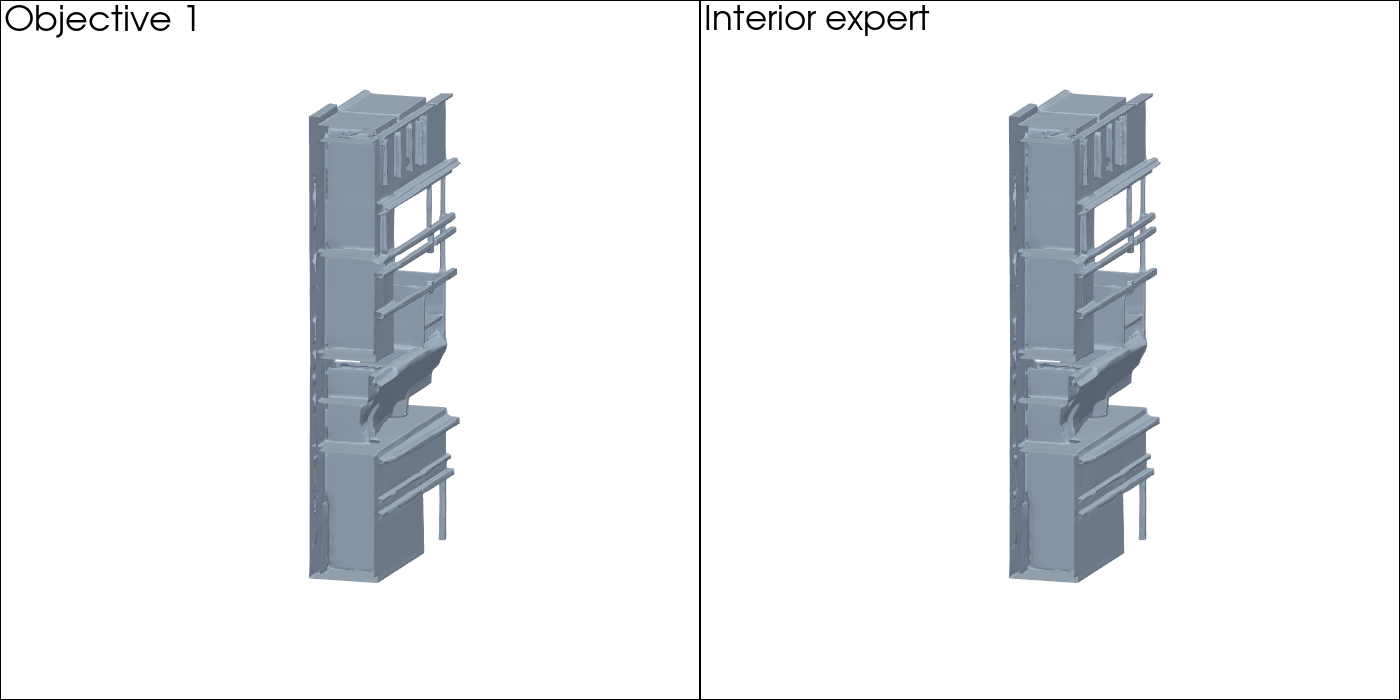

file_cabinet__e2763ac23ee84c6d91c352d02061b3f7


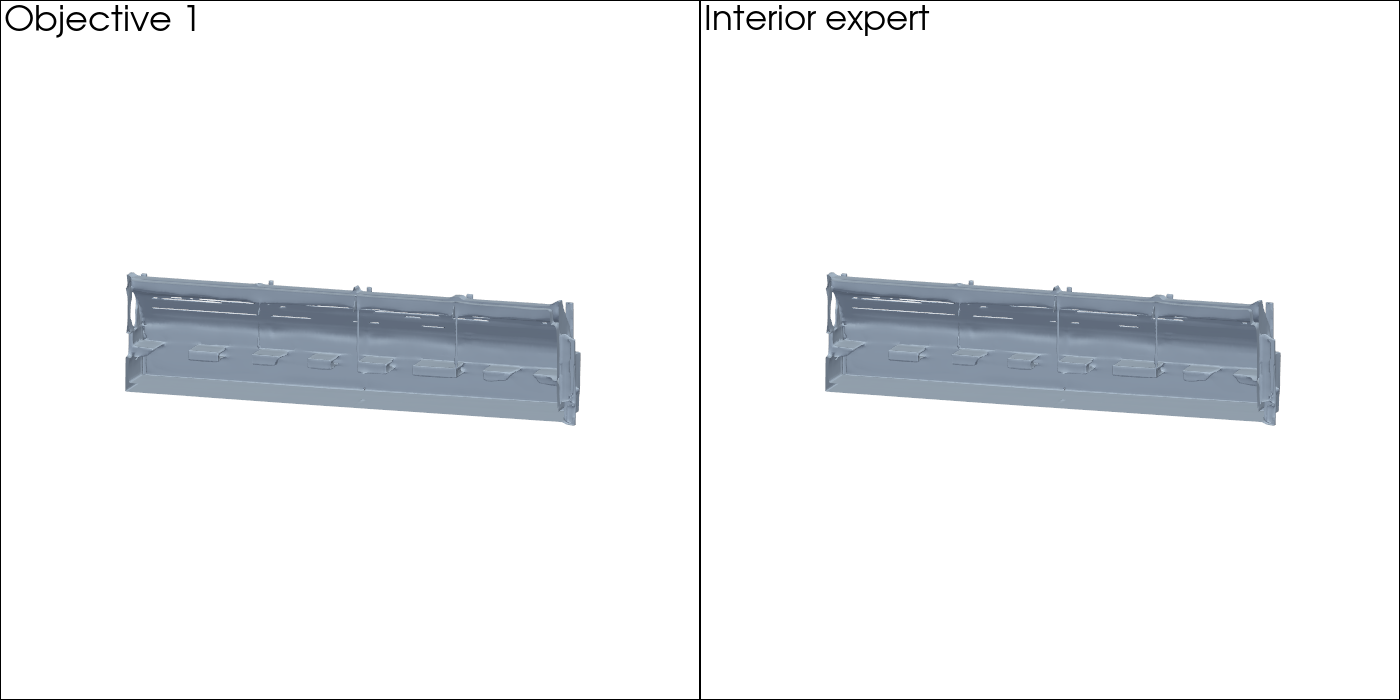

In [2]:
def camera_for_cut(normal):
    normal = normal / np.linalg.norm(normal)
    up = np.array([0.0, 0.0, 1.0])
    if abs(normal @ up) > 0.9:
        up = np.array([0.0, 1.0, 0.0])
    side = np.cross(up, normal)
    position = 2.0 * normal + 0.65 * side + 0.45 * up
    return [position.tolist(), [0.0, 0.0, 0.0], up.tolist()]


def render_comparison(sample_id):
    plotter = pv.Plotter(shape=(1, 2), off_screen=True, window_size=(1400, 700))
    for column, (method_label, mesh_dir) in enumerate(MESH_DIRS.items()):
        path = mesh_dir / f"{sample_id}.ply"
        if not path.is_file():
            raise FileNotFoundError(path)
        mesh = pv.read(path)
        cut = mesh.clip(normal=CUT_NORMAL, origin=CUT_ORIGIN, invert=True)

        plotter.subplot(0, column)
        plotter.set_background("white")
        plotter.add_mesh(
            cut, color="lightsteelblue", smooth_shading=True,
            ambient=0.25, diffuse=0.8, specular=0.15,
        )
        plotter.add_text(method_label, position="upper_left", color="black", font_size=14)

    plotter.link_views()
    plotter.camera_position = camera_for_cut(CUT_NORMAL)
    plotter.camera.parallel_projection = True
    plotter.camera.zoom(1.35)
    image = plotter.screenshot(return_img=True)
    plotter.close()
    return Image.fromarray(image)


for sample_id in sample_ids:
    print(sample_id)
    display(render_comparison(sample_id))